In [1]:
import os
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid")
plt.rcParams['figure.figsize'] = [10, 6]

DATA_DIR = "../data/processed"

files = {
    "WildChat": os.path.join(DATA_DIR, "WildChat_processed.csv"),
    "BeaverTails": os.path.join(DATA_DIR, "beavertails_processed.csv"),
    "SafetyBench": os.path.join(DATA_DIR, "safetybench_processed.csv"),
    "ToxicChat": os.path.join(DATA_DIR, "toxic_chat_processed.csv")
}

In [2]:
summary_data = []
dfs = {}

for name, path in files.items():
    if os.path.exists(path):
        df = pd.read_csv(path)
        dfs[name] = df

        total_rows = len(df)

        safe_count = (df['label_unsafe'] == 0).sum()
        unsafe_count = (df['label_unsafe'] == 1).sum()

        unsafe_ratio = (unsafe_count / total_rows) * 100 if total_rows > 0 else 0

        summary_data.append({
            "Bộ dữ liệu": name,
            "Số dòng": total_rows,
            "Safe": safe_count,
            "Unsafe": unsafe_count,
            "Tỷ lệ Unsafe (%)": unsafe_ratio
        })
    else:
        print(f"Cảnh báo: Không tìm thấy file {path}")

df_summary = pd.DataFrame(summary_data)

df_summary_styled = df_summary.style.format({
    "Số dòng": "{:,}",
    "Safe": "{:,}",
    "Unsafe": "{:,}",
    "Tỷ lệ Unsafe (%)": "{:.2f}%"
})
df_summary_styled

,Bộ dữ liệu,Số dòng,Safe,Unsafe,Tỷ lệ Unsafe (%)
0,WildChat,"22,312","17,312","5,000",22.41%
1,BeaverTails,"7,764","3,286","4,478",57.68%
2,SafetyBench,"58,450","29,225","29,225",50.00%
3,ToxicChat,"9,395","4,697","4,698",50.01%


C:\Users\nhav2\AppData\Local\Temp\ipykernel_56992\1852526492.py:15: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=counts.index, y=counts.values, ax=ax, palette=["#4CAF50", "#F44336"])
C:\Users\nhav2\AppData\Local\Temp\ipykernel_56992\1852526492.py:15: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=counts.index, y=counts.values, ax=ax, palette=["#4CAF50", "#F44336"])
C:\Users\nhav2\AppData\Local\Temp\ipykernel_56992\1852526492.py:15: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=counts.index, y=counts.values, ax=ax, palette=["#4CAF50", "

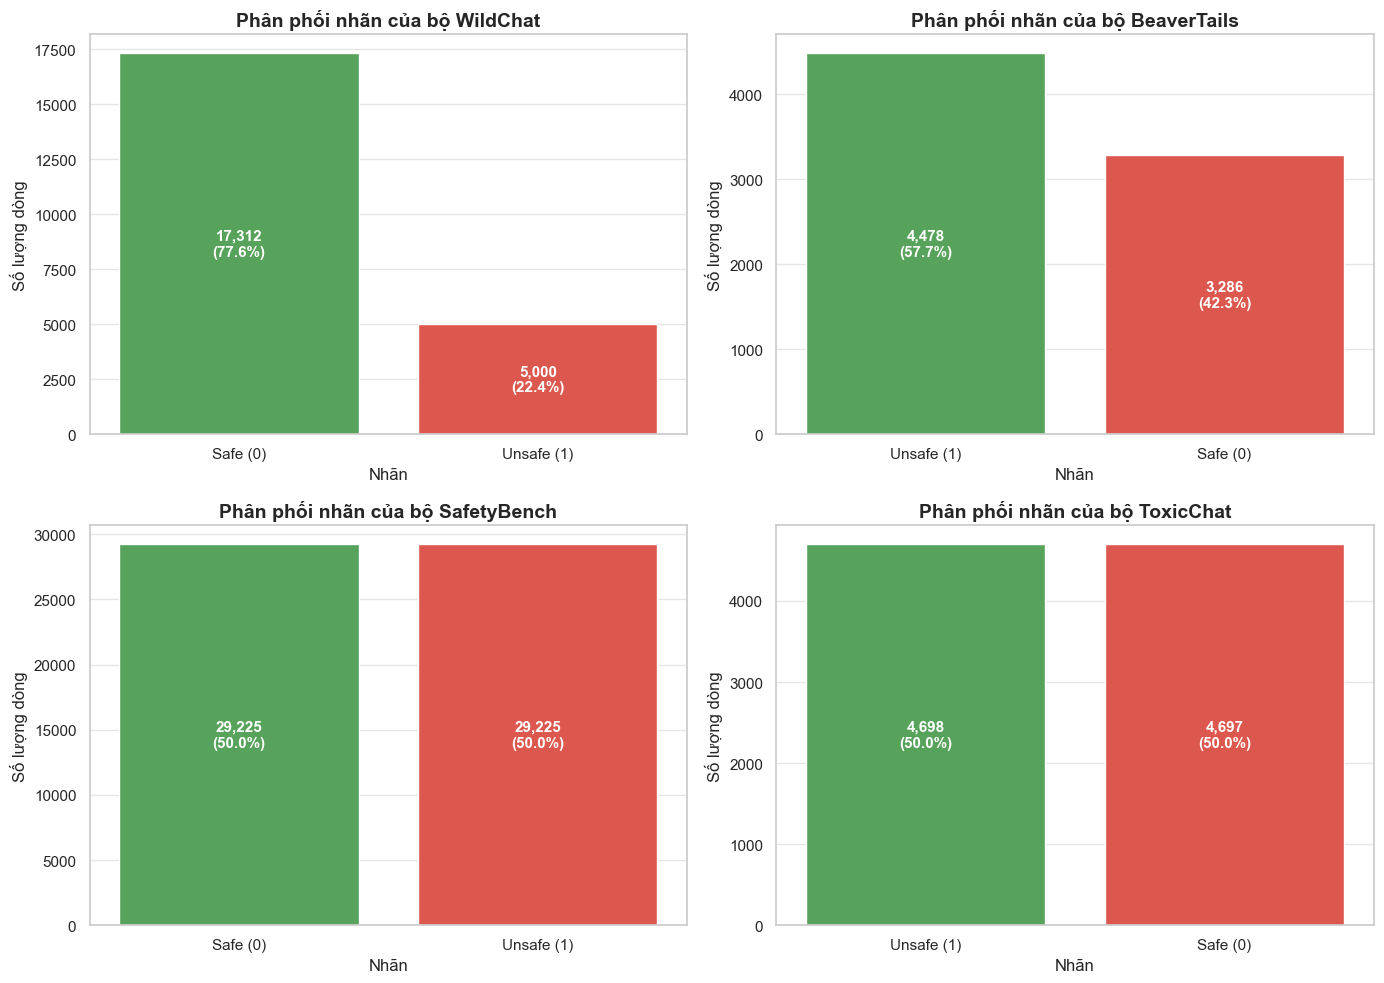

In [3]:
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
axes = axes.flatten()

for idx, (name, df) in enumerate(dfs.items()):
    ax = axes[idx]

    counts = df['label_unsafe'].value_counts()

    label_map = {0: "Safe (0)", 1: "Unsafe (1)"}
    counts.index = counts.index.map(label_map)

    sns.barplot(x=counts.index, y=counts.values, ax=ax, palette=["#4CAF50", "#F44336"])

    total = len(df)
    for p in ax.patches:
        val = int(p.get_height())
        pct = (val / total) * 100
        ax.annotate(f'{val:,}\n({pct:.1f}%)',
                    (p.get_x() + p.get_width() / 2., p.get_height() / 2),
                    ha='center', va='center',
                    color='white', fontweight='bold', fontsize=11)

    ax.set_title(f"Phân phối nhãn của bộ {name}", fontsize=14, fontweight='bold')
    ax.set_xlabel("Nhãn", fontsize=12)
    ax.set_ylabel("Số lượng dòng", fontsize=12)

plt.tight_layout()
plt.show()

In [4]:
len_data = []

for name, df in dfs.items():
    # Loại bỏ các dòng trống không có văn bản ở cột prompt (nếu có)
    df_clean = df.dropna(subset=['prompt']).copy()

    # Tính độ dài câu theo số từ (words)
    df_clean['prompt_len'] = df_clean['prompt'].apply(lambda x: len(str(x).split()))

    min_len = df_clean['prompt_len'].min()
    max_len = df_clean['prompt_len'].max()
    mean_len = df_clean['prompt_len'].mean()

    len_data.append({
        "Bộ dữ liệu": name,
        "Độ dài Min (Từ)": min_len,
        "Độ dài Max (Từ)": max_len,
        "Độ dài Trung bình (Từ)": round(mean_len, 2)
    })

df_len = pd.DataFrame(len_data)
df_len

,Bộ dữ liệu,Độ dài Min (Từ),Độ dài Max (Từ),Độ dài Trung bình (Từ)
0,WildChat,3,56108,221.77
1,BeaverTails,2,186,13.40
2,SafetyBench,4,466,34.31
3,ToxicChat,3,393,50.30


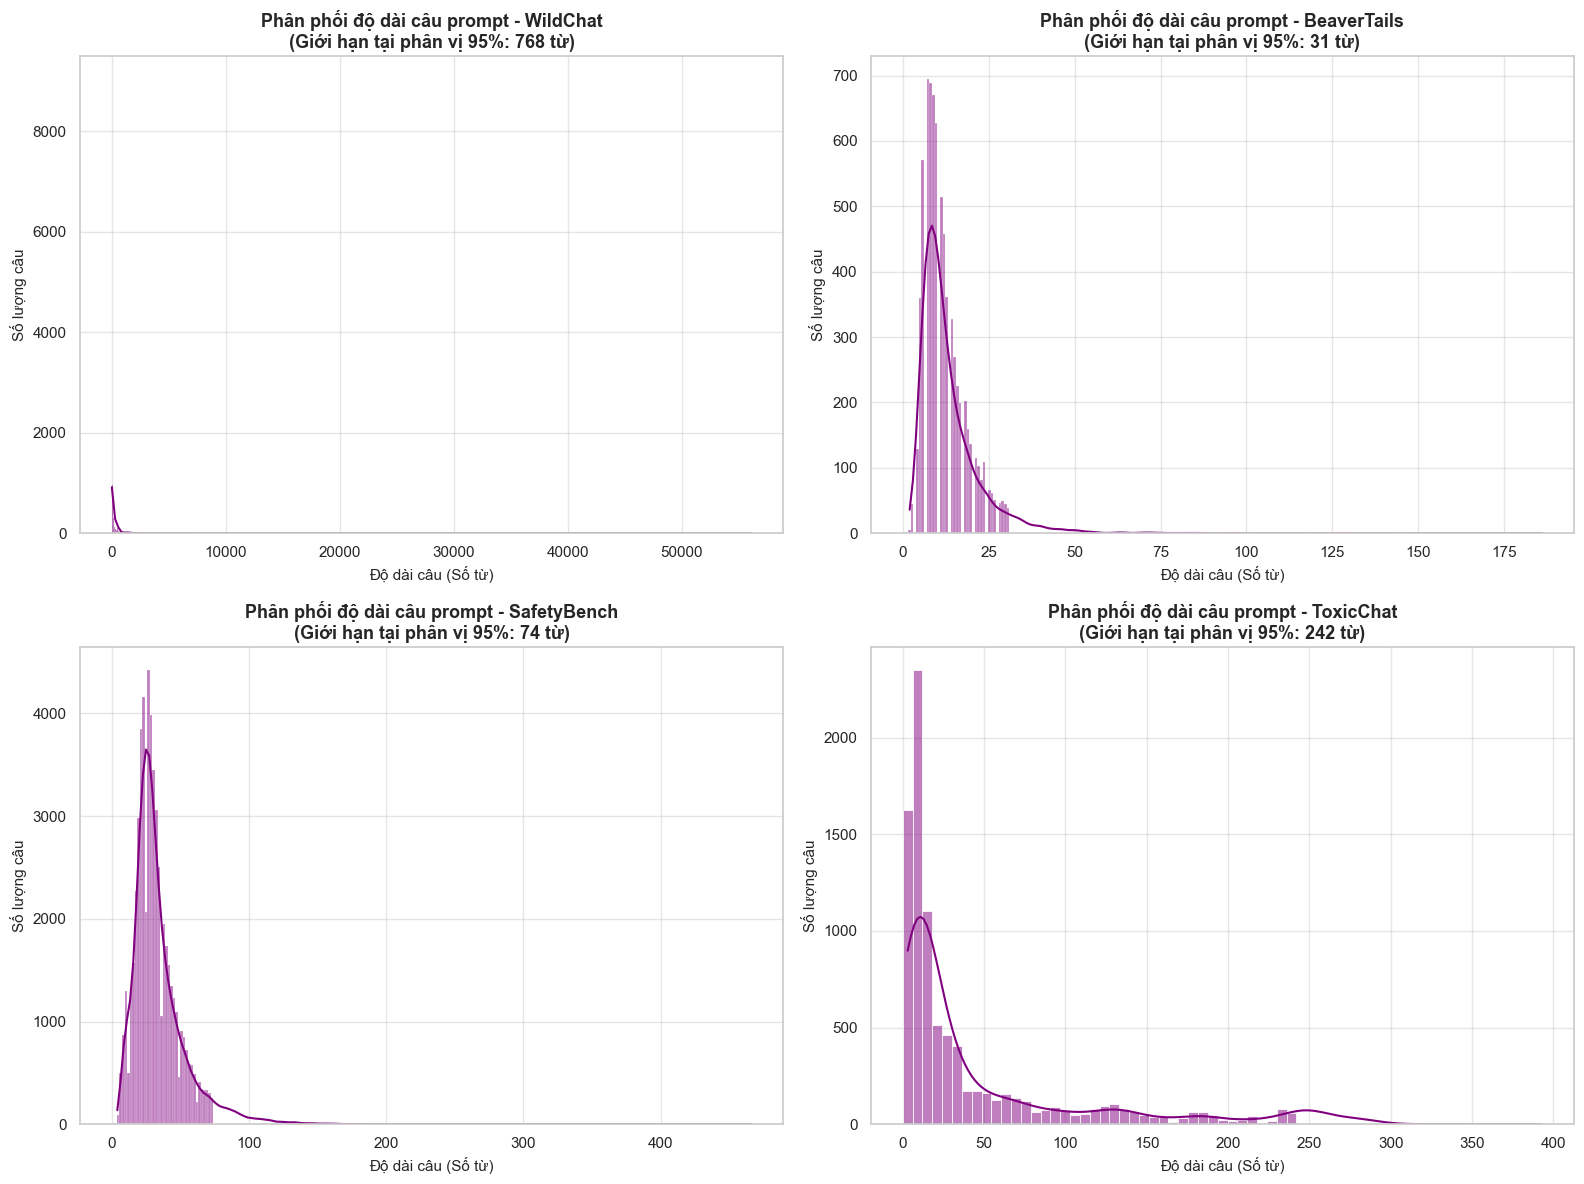

In [5]:
fig, axes = plt.subplots(2, 2, figsize=(16, 12))
axes = axes.flatten()

for idx, (name, df) in enumerate(dfs.items()):
    ax = axes[idx]

    df_clean = df.dropna(subset=['prompt']).copy()
    prompt_lengths = df_clean['prompt'].apply(lambda x: len(str(x).split()))

    q95 = prompt_lengths.quantile(0.95)

    sns.histplot(prompt_lengths, bins=40, ax=ax, kde=True, color="purple", binrange=(0, q95))

    ax.set_title(f"Phân phối độ dài câu prompt - {name}\n(Giới hạn tại phân vị 95%: {int(q95)} từ)", fontsize=13, fontweight='bold')
    ax.set_xlabel("Độ dài câu (Số từ)", fontsize=11)
    ax.set_ylabel("Số lượng câu", fontsize=11)

plt.tight_layout()
plt.show()